In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import glob
from scipy.interpolate import interp1d

In [47]:
path_dfs = Path('/Volumes/KINGSTON/RaTag_data/processed/dfs')
files_raw = path_dfs.glob('*.csv')
files = sorted([f for f in files_raw if not f.name.startswith('._')])

[f.name for f in files]

['RUN37_s2_vs_field_multiiso.csv',
 'RUN38_s2_vs_field_multiiso.csv',
 'RUN39_s2_vs_field_multiiso.csv',
 'RUN40_s2_vs_field_multiiso.csv',
 'RUN41_s2_vs_field_multiiso.csv']

In [48]:
df_dict = {}
for f in files:
    df = pd.read_csv(f)
    df_dict[f.name[:5]] = df

In [66]:
# Grab only Isotope Th228 data
# df_th228 = {}
# for key in df_dict.keys():
#     df_th228[key] = df_dict[key][df_dict[key]['isotope'] == 'Th228']

df_iso = {}
for iso in ['Th228', 'Ra224', 'Po216', 'Po212']:
    df_iso[iso] = {}
    for key2 in df_dict.keys():
        df_iso[iso][key2] = df_dict[key2][df_dict[key2]['isotope'] == iso]

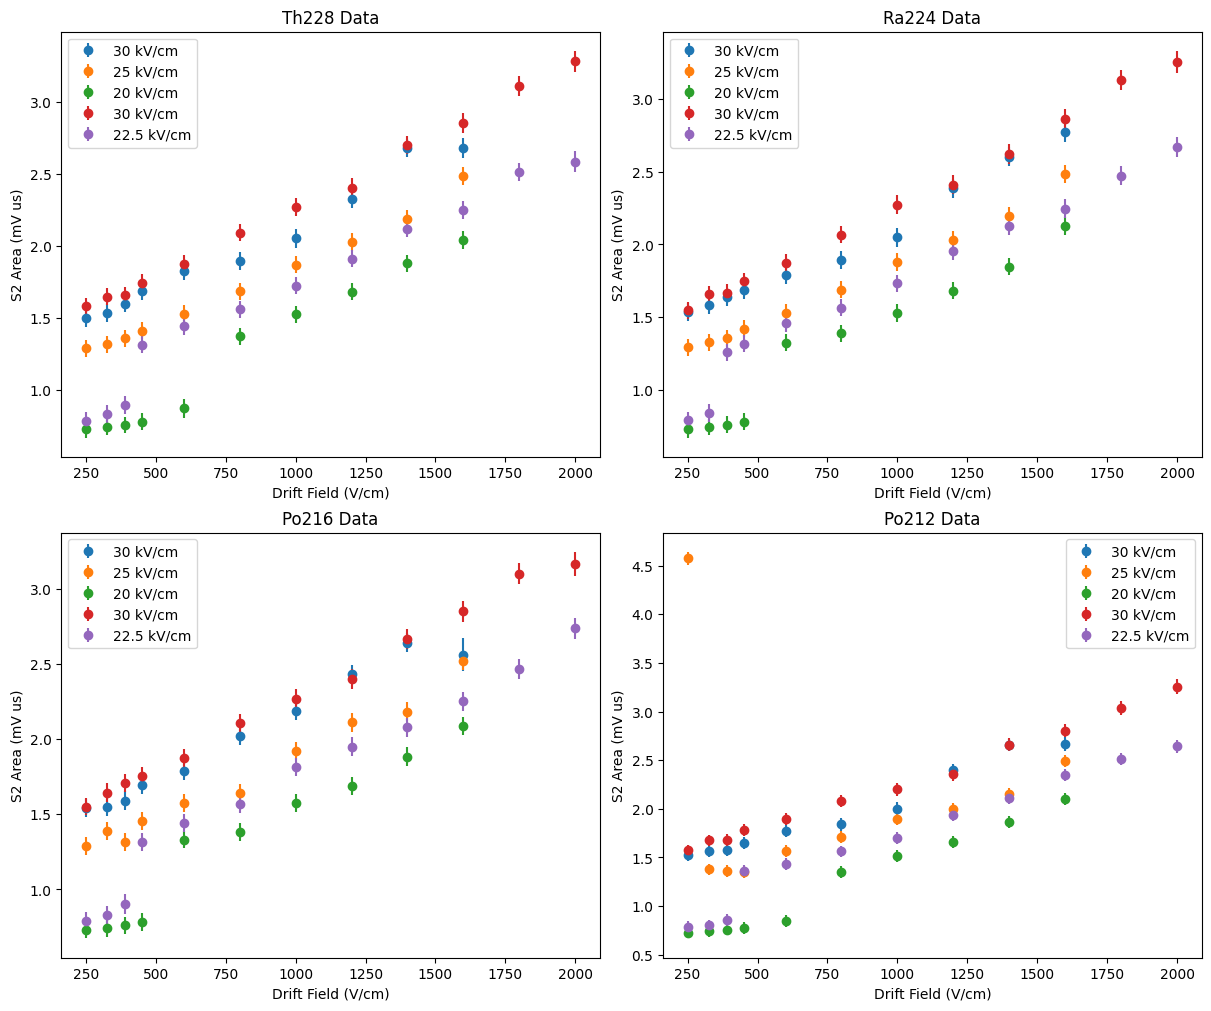

In [68]:
el_field_dict = {
    'RUN37': 30,
    'RUN38': 25,
    'RUN39': 20,
    'RUN40': 30,
    'RUN41': 22.5,
}
fig, ax = plt.subplots(2, 2, figsize=(12, 10), layout='constrained')
for iso, ax in zip(['Th228', 'Ra224', 'Po216', 'Po212'], ax.flatten()):
    for key, df in df_iso[iso].items():
        ax.errorbar(df['drift_field'], df['s2_mean'], yerr=df['s2_ci95'], fmt='o', label=str(el_field_dict.get(key, key))+' kV/cm')
    ax.set(xlabel='Drift Field (V/cm)', ylabel='S2 Area (mV us)', title=iso+' Data')
    ax.legend()
# for key, df in df_iso['Th228'].items():
#     plt.errorbar(df['drift_field'], df['s2_mean'], yerr=df['s2_ci95'], fmt='o', label=str(el_field_dict.get(key, key))+' kV/cm')
# plt.gca().set(xlabel='Drift Field (V/cm)', ylabel='S2 Area (mV us)', title='Th228 Data')
# plt.legend()